## The Kulturkampf and Catholic Fertility in Prussia
# 
### **Research question:** Did Bismarck's anti-Catholic Kulturkampf legislation 
#### (1872–1878) affect the Catholic–Protestant fertility differential in Prussian counties?
#
# **Data:** Galloway Prussia Database (1861–1914) + iPEHD (1871)

# Cell 1: Setup

In [2]:
import sys
from pathlib import Path
 
# Add project root to path so we can import from src/
project_root = Path.cwd().parent  # assumes notebook is in notebooks/
sys.path.insert(0, str(project_root))
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
from src.load_data import load_rel1871, load_vit_panel, load_ipehd_master
from src.build_dataset import build_analysis_panel
from src.regressions import run_baseline_did, run_event_study, run_robustness
from src.plots import (
    plot_fertility_trends, 
    plot_event_study, 
    plot_cath_distribution,
    plot_robustness_table,
)
 
# Paths
DATA_RAW = project_root / "data" / "raw"
OUTPUTS = project_root / "outputs"
OUTPUTS.mkdir(exist_ok=True)
 
print("Setup complete.")
print(f"Raw data directory: {DATA_RAW}")
print(f"Files found: {sorted([f.name for f in DATA_RAW.glob('*.XLSX')])[:10]}...")

Setup complete.
Raw data directory: c:\Users\Anton\Demography\exam_project2\data\raw
Files found: ['REL1871.xlsx', 'VIT1875.xlsx', 'VIT1876.xlsx', 'VIT1877.xlsx', 'VIT1878.xlsx']...


### Cell 2: Build the analysis panel

In [3]:
panel = build_analysis_panel(
    data_dir=DATA_RAW,
    year_start=1862,
    year_end=1890,
    save=True,
)
 
panel.head(10)

REL1871: 393 counties loaded
Loaded VIT panel: 11493 observations, 486 counties, years 1862-1890
Poptot missing for 3632 obs — interpolating from POP census files...
  POP1861: 326 counties loaded
  POP1864: 313 counties loaded
  POP1867: 410 counties loaded
  POP1871: 393 counties loaded
  POP1875: 407 counties loaded
  POP1880: 405 counties loaded
  POP1885: 431 counties loaded
  POP1890: 451 counties loaded
Population interpolation complete — no missing values.
Merge: 486 VIT counties → 392 matched with REL1871 (94 dropped)
Saved to C:\Users\Anton\Demography\exam_project2\data\processed\analysis_panel.parquet

Analysis panel: 10784 obs, 392 counties, 1862-1890
High-Catholic counties (>50%): 130
Low-Catholic counties (≤50%):  262
Mean CBR: 39.1 per 1,000


,Code,Rb,Kreis,Type,Year,Poptot,Birtot,Birlegtot,Birbastot,Dthtot,...,illegitimacy_ratio,marriage_rate,cath_marriage_share,infant_mortality_rate,ln_pop,post_kulturkampf,high_cath,treat_x_post,cath_share_x_post,cbr_flag
0,1,KON,MEMEL,0.0,1862,53505.000000,1974,1792,182,1531,...,9.219858,8.298290,NaN,60.825893,10.887530,0,0,0,0.0,False
1,1,KON,MEMEL,0.0,1863,53505.000000,2056,1886,170,1373,...,8.268482,8.746846,NaN,99.681866,10.887530,0,0,0,0.0,False
2,1,KON,MEMEL,0.0,1864,53505.000000,2209,1984,225,1444,...,10.185604,9.008504,NaN,83.669355,10.887530,0,0,0,0.0,False
3,1,KON,MEMEL,0.0,1865,54472.666667,2104,1926,178,1378,...,8.460076,8.628180,NaN,53.478712,10.905454,0,0,0,0.0,False
4,1,KON,MEMEL,0.0,1866,55440.333333,2017,1841,176,2031,...,8.725830,7.052627,NaN,63.552417,10.923063,0,0,0,0.0,False
5,1,KON,MEMEL,0.0,1867,56408.000000,2118,1953,165,1671,...,7.790368,8.686711,NaN,74.244752,10.940366,0,0,0,0.0,False
6,1,KON,MEMEL,0.0,1868,56295.500000,1829,1641,188,2078,...,10.278841,7.691556,NaN,123.705058,10.938370,0,0,0,0.0,False
7,1,KON,MEMEL,0.0,1869,56183.000000,2000,1830,170,1806,...,8.500000,7.511169,NaN,62.295082,10.936369,0,0,0,0.0,False
8,1,KON,MEMEL,0.0,1870,56070.500000,1959,1774,185,1611,...,9.443594,7.169545,NaN,96.392334,10.934365,0,0,0,0.0,False
9,1,KON,MEMEL,0.0,1871,55958.000000,1725,1532,193,1599,...,11.188406,9.060367,NaN,105.744125,10.932357,0,0,0,0.0,False


### Cell 3: Descriptive statistics

In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
 
# Summary by period
for period, label in [(panel["Year"] < 1873, "Pre-Kulturkampf (1862-1872)"),
                       (panel["Year"] >= 1873, "Post-Kulturkampf (1873-1890)")]:
    sub = panel[period]
    print(f"\n{label}:")
    print(f"  N = {len(sub)}, Counties = {sub['Code'].nunique()}")
    for var in ["cbr", "legitimate_br", "marriage_rate"]:
        if var in sub.columns and sub[var].notna().any():
            print(f"  {var}: mean={sub[var].mean():.2f}, sd={sub[var].std():.2f}")
 
# Summary by Catholic share group
print(f"\n{'='*60}")
print("BY RELIGIOUS COMPOSITION (full sample)")
print(f"{'='*60}")
grouped = panel.groupby("high_cath").agg(
    n_counties=("Code", "nunique"),
    mean_cath_share=("cath_share", "mean"),
    mean_cbr=("cbr", "mean"),
    mean_marriage_rate=("marriage_rate", lambda x: x.mean() if x.notna().any() else np.nan),
).round(2)
grouped.index = ["Low Catholic (≤50%)", "High Catholic (>50%)"]
print(grouped)

DESCRIPTIVE STATISTICS

Pre-Kulturkampf (1862-1872):
  N = 3835, Counties = 390
  cbr: mean=38.91, sd=6.00
  legitimate_br: mean=35.84, sd=5.76
  marriage_rate: mean=8.28, sd=1.41

Post-Kulturkampf (1873-1890):
  N = 6949, Counties = 392
  cbr: mean=39.24, sd=5.44
  legitimate_br: mean=36.30, sd=5.25
  marriage_rate: mean=7.91, sd=1.11

BY RELIGIOUS COMPOSITION (full sample)
                      n_counties  mean_cath_share  mean_cbr  \
Low Catholic (≤50%)          262             9.31     38.60   
High Catholic (>50%)         130            84.02     40.14   

                      mean_marriage_rate  
Low Catholic (≤50%)                 8.18  
High Catholic (>50%)                7.78  


### Cell 4: Distribution of Catholic shares

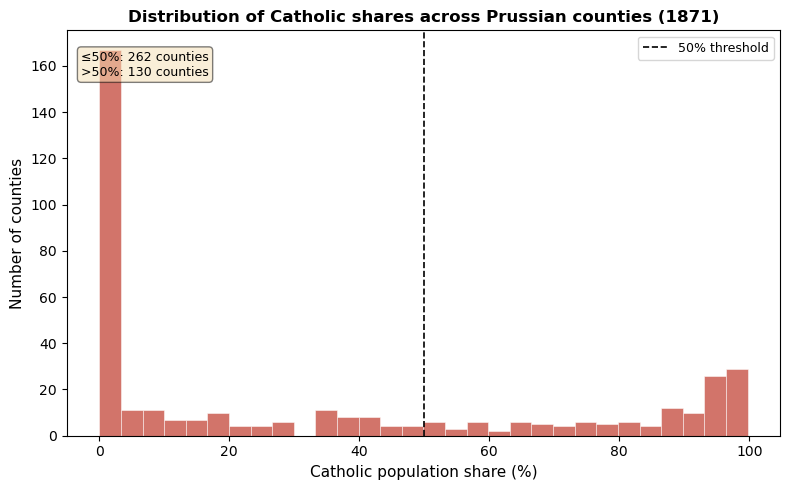

In [26]:
fig, ax = plot_cath_distribution(
    panel,
    savepath=str(OUTPUTS / "fig1_cath_distribution.png"),
)
plt.show()

### Cell 5: Fertility trends over time

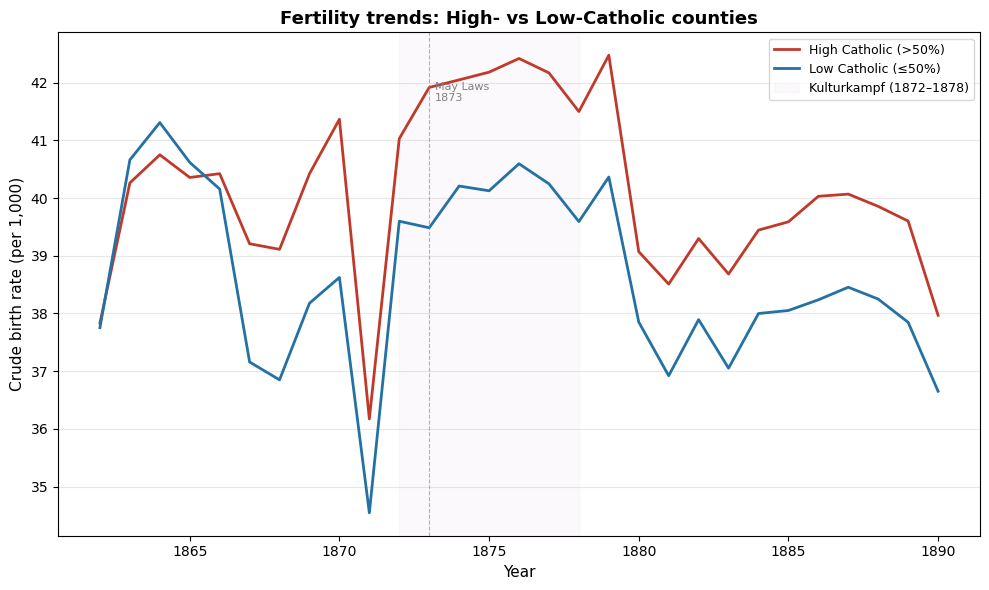

In [27]:
fig, ax = plot_fertility_trends(
    panel,
    outcome="cbr",
    ylabel="Crude birth rate (per 1,000)",
    title="Fertility trends: High- vs Low-Catholic counties",
    savepath=str(OUTPUTS / "fig2_fertility_trends.png"),
)
plt.show()

### Cell 6: Fertility trends – legitimate births only
(Only available from 1875 when detailed VIT files start)

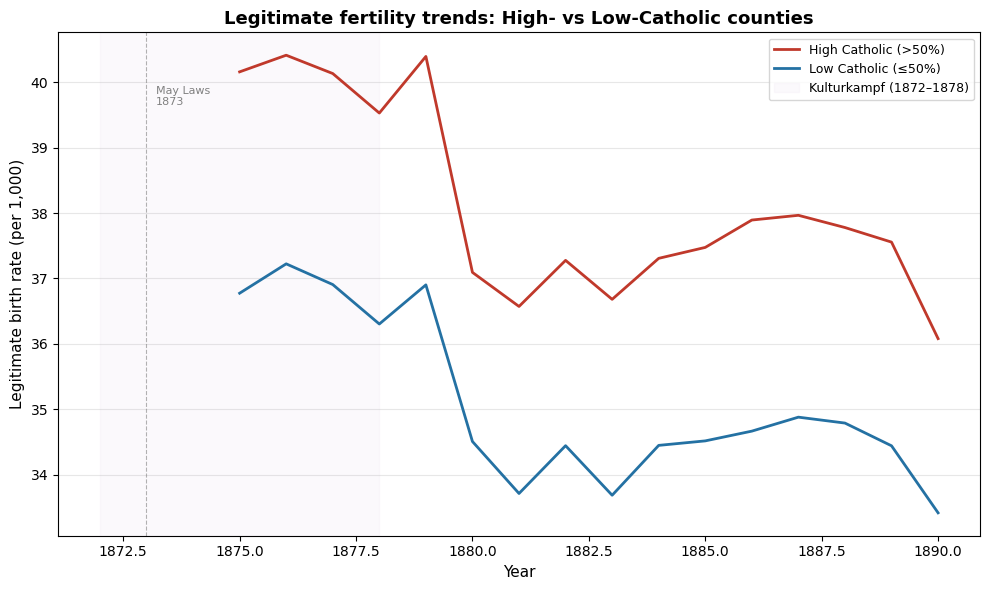

In [28]:
panel_post75 = panel[panel["Year"] >= 1875].copy()
 
fig, ax = plot_fertility_trends(
    panel_post75,
    outcome="legitimate_br",
    ylabel="Legitimate birth rate (per 1,000)",
    title="Legitimate fertility trends: High- vs Low-Catholic counties",
    savepath=str(OUTPUTS / "fig3_legit_fertility_trends.png"),
)
plt.show()

### Cell 7: Marriage trends by religion
### Catholic marriage share only available from 1875

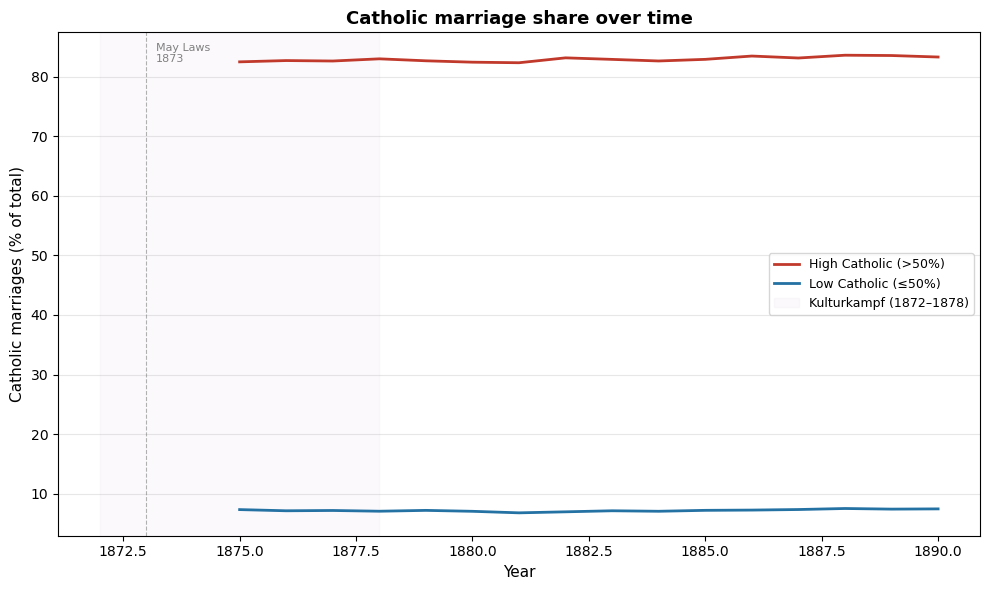

In [7]:
fig, ax = plot_fertility_trends(
    panel_post75,
    outcome="cath_marriage_share",
    ylabel="Catholic marriages (% of total)",
    title="Catholic marriage share over time",
    savepath=str(OUTPUTS / "fig4_cath_marriages.png"),
)
plt.show()

### Cell 8: Baseline DiD – Continuous treatment

In [8]:
print("=" * 60)
print("BASELINE DiD: CBR ~ CathShare × Post")
print("=" * 60)
 
res_cont = run_baseline_did(
    panel,
    outcome="cbr",
    treatment="continuous",
)
print(res_cont["summary"])


BASELINE DiD: CBR ~ CathShare × Post
                          PanelOLS Estimation Summary                           
Dep. Variable:                    cbr   R-squared:                        0.0023
Estimator:                   PanelOLS   R-squared (Between):              0.5161
No. Observations:               10784   R-squared (Within):              -0.0018
Date:                 sø, apr 12 2026   R-squared (Overall):              0.5131
Time:                        21:49:03   Log-likelihood                -2.439e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.153
Entities:                         392   P-value                           0.0000
Avg Obs:                       27.510   Distribution:                 F(2,10362)
Min Obs:                       13.000                                           
Max Obs:                       29.000   F-statistic (robust):           

### Cell 9: Baseline DiD – Binary treatment

In [9]:
print("=" * 60)
print("BASELINE DiD: CBR ~ HighCath × Post")
print("=" * 60)
 
res_bin = run_baseline_did(
    panel,
    outcome="cbr",
    treatment="binary",
)
print(res_bin["summary"])

BASELINE DiD: CBR ~ HighCath × Post
                          PanelOLS Estimation Summary                           
Dep. Variable:                    cbr   R-squared:                        0.0023
Estimator:                   PanelOLS   R-squared (Between):              0.5156
No. Observations:               10784   R-squared (Within):              -0.0013
Date:                 sø, apr 12 2026   R-squared (Overall):              0.5126
Time:                        21:49:22   Log-likelihood                -2.439e+04
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      12.196
Entities:                         392   P-value                           0.0000
Avg Obs:                       27.510   Distribution:                 F(2,10362)
Min Obs:                       13.000                                           
Max Obs:                       29.000   F-statistic (robust):            

### Cell 10: DiD for other outcomes

In [11]:
print("=" * 60)
print("DiD FOR ALTERNATIVE OUTCOMES")
print("=" * 60)
 
for outcome, label in [
    ("legitimate_br", "Legitimate birth rate"),
    ("marriage_rate", "Marriage rate"),
    ("illegitimacy_ratio", "Illegitimacy ratio"),
]:
    print(f"\n--- {label} ---")
    try:
        res = run_baseline_did(panel, outcome=outcome, treatment="continuous")
        r = res["result"]
        treat_var = "cath_share_x_post"
        print(f"  Coef: {r.params[treat_var]:.4f} "
              f"(SE: {r.std_errors[treat_var]:.4f}, "
              f"p: {r.pvalues[treat_var]:.3f})")
    except Exception as e:
        print(f"  Error: {e}")

DiD FOR ALTERNATIVE OUTCOMES

--- Legitimate birth rate ---
  Coef: 0.0003 (SE: 0.0037, p: 0.935)

--- Marriage rate ---
  Coef: -0.0038 (SE: 0.0009, p: 0.000)

--- Illegitimacy ratio ---
  Coef: -0.0025 (SE: 0.0018, p: 0.164)


### Cell 11: Event study

EVENT STUDY


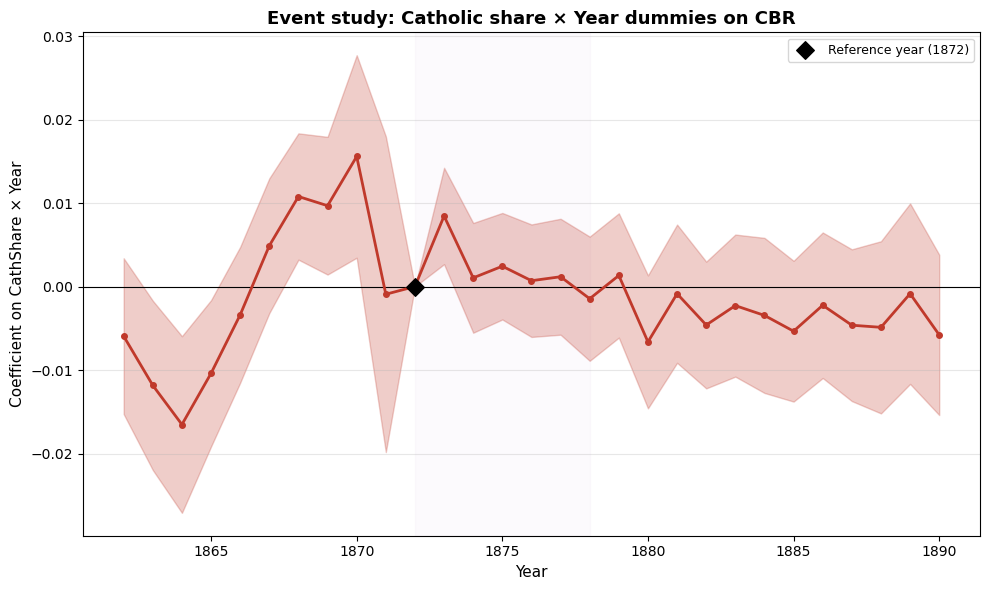


Pre-trend coefficients (before 1872):
 Year      beta       se
 1862 -0.005944 0.004759
 1863 -0.011836 0.005173
 1864 -0.016524 0.005396
 1865 -0.010391 0.004469
 1866 -0.003386 0.004148
 1867  0.004889 0.004118
 1868  0.010781 0.003859
 1869  0.009679 0.004207
 1870  0.015576 0.006186
 1871 -0.000924 0.009644


In [10]:
print("=" * 60)
print("EVENT STUDY")
print("=" * 60)
 
es = run_event_study(
    panel,
    outcome="cbr",
    treatment_var="cath_share",
    ref_year=1872,
)
 
fig, ax = plot_event_study(
    es["coefs"],
    ref_year=1872,
    title="Event study: Catholic share × Year dummies on CBR",
    savepath=str(OUTPUTS / "fig5_event_study.png"),
)
plt.show()
 
# Print pre-trend test: are pre-1872 coefficients jointly zero?
pre_coefs = es["coefs"][es["coefs"]["Year"] < 1872]
print(f"\nPre-trend coefficients (before 1872):")
print(pre_coefs[["Year", "beta", "se"]].to_string(index=False))

### Cell 12: Robustness checks

ROBUSTNESS CHECKS
                         Specification  Coefficient       SE  p_value     N  N_counties
Baseline (continuous CathShare × Post)    -0.001613 0.003756 0.667699 10784         392
          Binary (HighCath>50% × Post)    -0.132857 0.287496 0.644007 10784         392
                    Post cutoff = 1872    -0.001541 0.003853 0.689218 10784         392
                    Post cutoff = 1875    -0.003192 0.003535 0.366541 10784         392
                Binary threshold = 25%    -0.304558 0.252999 0.228698 10784         392
                Binary threshold = 75%    -0.145945 0.353969 0.680121 10784         392
                Excl. Polish provinces    -0.000343 0.003939 0.930644 10088         368


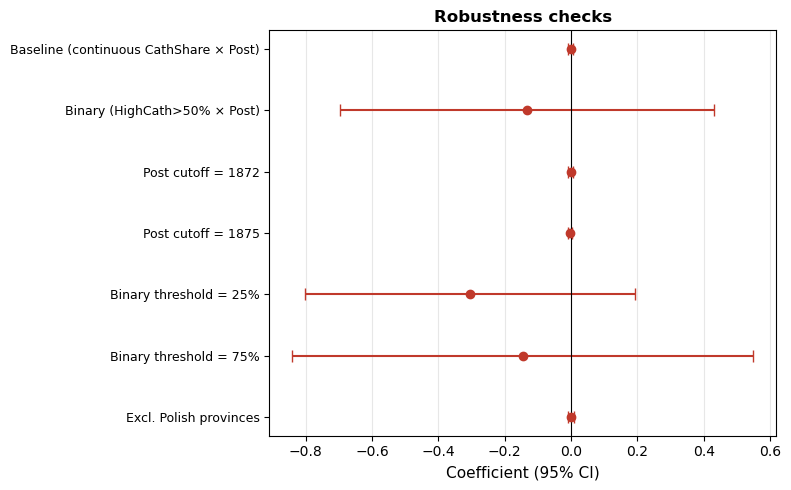

In [12]:
print("=" * 60)
print("ROBUSTNESS CHECKS")
print("=" * 60)
 
rob = run_robustness(panel, outcome="cbr")
print(rob.to_string(index=False))
 
fig, ax = plot_robustness_table(
    rob,
    savepath=str(OUTPUTS / "fig6_robustness.png"),
)
plt.show()

### Cell 13: Validate against iPEHD

In [14]:
print("=" * 60)
print("VALIDATION: Compare Catholic shares with iPEHD")
print("=" * 60)
 
ipehd = load_ipehd_master(DATA_RAW / "ipehd_qje2009_master.dta")
rel = load_rel1871(DATA_RAW / "REL1871.XLSX")
 
# The two datasets use different county codes, so we compare distributions
print(f"iPEHD f_cath: mean={ipehd['f_cath'].mean():.1f}, "
      f"median={ipehd['f_cath'].median():.1f}, N={len(ipehd)}")
print(f"Galloway cath_share: mean={rel['cath_share'].mean():.1f}, "
      f"median={rel['cath_share'].median():.1f}, N={len(rel)}")
print("\nDistributions should be similar (not identical due to different")
print("sample definitions and Stadt/Land handling).")

VALIDATION: Compare Catholic shares with iPEHD
iPEHD f_cath: mean=34.5, median=14.8, N=452
Galloway cath_share: mean=33.9, median=12.9, N=393

Distributions should be similar (not identical due to different
sample definitions and Stadt/Land handling).


### Cell 14: Setup exploratory analyses

In [4]:
from src.exploratory import (
    heterogeneity_by_urbanization,
    polish_vs_german_catholics,
    fertility_convergence,
    marriage_to_birth_pipeline,
    dose_response_plot,
    infant_mortality_did,
)

### Cell 15: Urban vs Rural heterogeneity

In [5]:
print("=" * 60)
print("HETEROGENEITY: URBAN vs RURAL")
print("=" * 60)
het_results = heterogeneity_by_urbanization(panel, outcome="cbr")

HETEROGENEITY: URBAN vs RURAL
Urban: β = -0.0142 (SE = 0.0071, p = 0.045)
Rural: β = 0.0084 (SE = 0.0038, p = 0.027)

Triple difference (CathShare × Post × Urban):
  β = -0.0221 (SE = 0.0079, p = 0.005)


### Cell 16: Polish vs German Catholics

In [6]:
print("=" * 60)
print("POLISH vs GERMAN CATHOLICS")
print("=" * 60)
pol_results = polish_vs_german_catholics(panel, outcome="cbr")

POLISH vs GERMAN CATHOLICS
Polish Catholic provinces (24 counties): β = -0.0676 (SE = 0.0146, p = 0.000)
German Catholic provinces (68 counties): β = 0.0215 (SE = 0.0125, p = 0.085)
Protestant provinces (rest) (300 counties): β = -0.0017 (SE = 0.0040, p = 0.676)


### Cell 17: Fertility convergence

FERTILITY CONVERGENCE
β-convergence regression: ΔCBR = -0.88 + 0.0060 × CathShare
  SE = 0.0050, p = 0.231, R² = 0.005
  N = 302 counties
  → Higher Catholic share predicts SMALLER fertility decline (divergence)


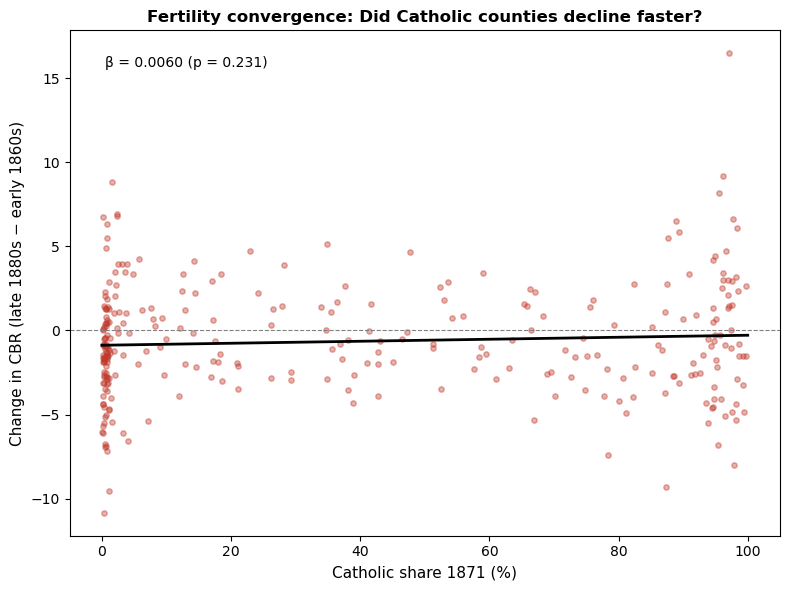

In [19]:
print("=" * 60)
print("FERTILITY CONVERGENCE")
print("=" * 60)
fig_conv, conv_data = fertility_convergence(panel)
fig_conv.savefig(OUTPUTS / "fig7_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

### Cell 18: Marriage to birth pipeline (lagged effects)

In [20]:
print("=" * 60)
print("MARRIAGE → BIRTH PIPELINE (LAGGED EFFECTS)")
print("=" * 60)
lag_results = marriage_to_birth_pipeline(panel)

MARRIAGE → BIRTH PIPELINE (LAGGED EFFECTS)


IndexError: boolean index did not match indexed array along dimension 0; dimension is 10784 but corresponding boolean dimension is 10798

### Cell 19: Dose-response plot

DOSE-RESPONSE BY CATHOLIC SHARE BIN
    bin   pre_cbr  post_cbr    change  n_counties
   0-5% 37.873168 38.075763  0.202595         173
  5-20% 38.727140 39.336687  0.609547          40
 20-50% 40.254386 40.210382 -0.044004          49
 50-80% 43.208056 43.178278 -0.029778          43
 80-95% 39.851384 40.357336  0.505952          47
95-100% 35.931175 37.422332  1.491156          40


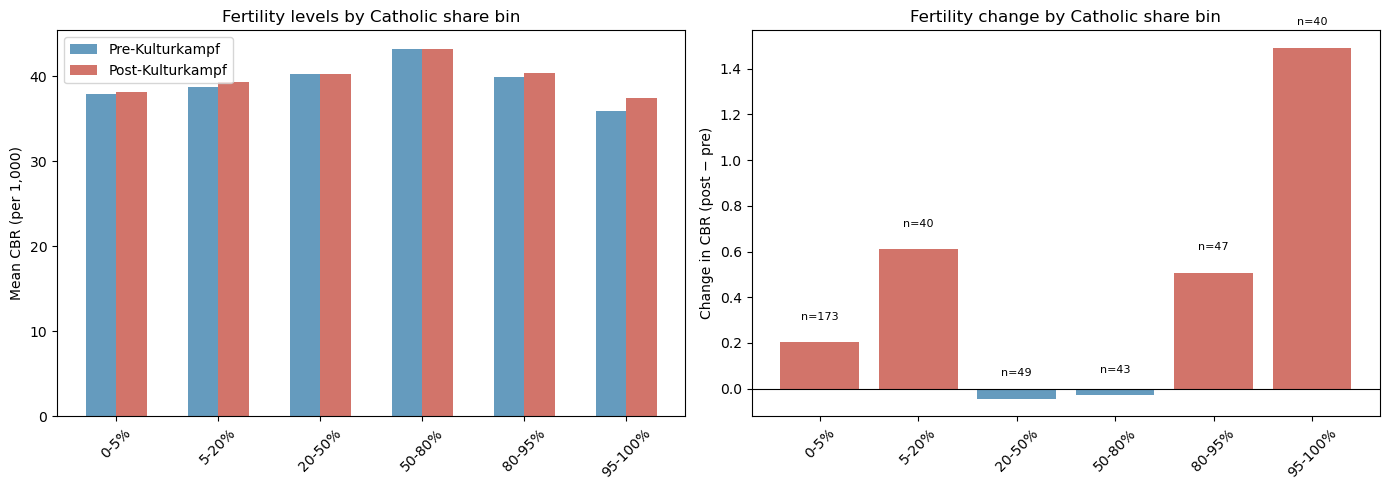

In [21]:
print("=" * 60)
print("DOSE-RESPONSE BY CATHOLIC SHARE BIN")
print("=" * 60)
fig_dose, dose_data = dose_response_plot(
    panel, savepath=str(OUTPUTS / "fig8_dose_response.png")
)
plt.show()

### Cell 20: Infant mortality channel

In [22]:
print("=" * 60)
print("INFANT MORTALITY CHANNEL")
print("=" * 60)
imr_result = infant_mortality_did(panel)

INFANT MORTALITY CHANNEL


IndexError: boolean index did not match indexed array along dimension 0; dimension is 10784 but corresponding boolean dimension is 10790

## Notes on identification
 
**What this design can show:**
- Whether the Catholic–Protestant fertility differential changed around the Kulturkampf period - Whether the timing lines up with the legislation (event study)

**What this design CANNOT show:**
- Clean causal effect: Catholic share is not randomly assigned. Counties differ in urbanisation, occupational structure, literacy, etc. - County + year fixed effects absorb time-invariant county differences and common shocks, but cannot rule out differential trends correlated with Catholic share

**Key threats to identification:**
1. The Kulturkampf was a *response* to Catholic political mobilisation, not a random shock
2. Catholic and Protestant counties may have been on different fertility trajectories for other reasons (industrialisation, urbanisation)
3. The event study pre-trends test is essential: if coefficients are already trending before 1872, the DiD is compromised
 
**This is fine for a course paper** — the examiner values transparent discussion of these limitations.

# %% Cell 21: Rollback event study

In [10]:
from src.advanced import (
    rollback_event_study,
    illegitimacy_analysis,
    infant_mortality_analysis,
    franco_prussian_war_analysis,
    robustness_exclude_war
)

print("=" * 60)
print("ROLLBACK EVENT STUDY")
print("=" * 60)
rollback = rollback_event_study(
    panel,
    outcome="cbr",
    treatment_var="cath_share",
    ref_year=1872,
    savepath=str(OUTPUTS / "fig9_rollback_event_study.png"),
)
plt.show()

ImportError: cannot import name 'robustness_exclude_war' from 'src.advanced' (c:\Users\Anton\Demography\exam_project2\src\advanced.py)

# %% Cell 22: Illegitimacy analysis

ILLEGITIMACY CHANNEL

Mean illegitimacy ratio (% of births):
  Pre-Kulturkampf (1875-1878):
    Low Catholic (≤50%):  8.31%
    High Catholic (>50%): 4.69%
  Rollback (1880-1887):
    Low Catholic (≤50%):  9.05%
    High Catholic (>50%): 5.12%

DiD: Illegitimacy ratio ~ CathShare × Post
  β = -0.0025 (SE = 0.0018, p = 0.164)
  N = 10783


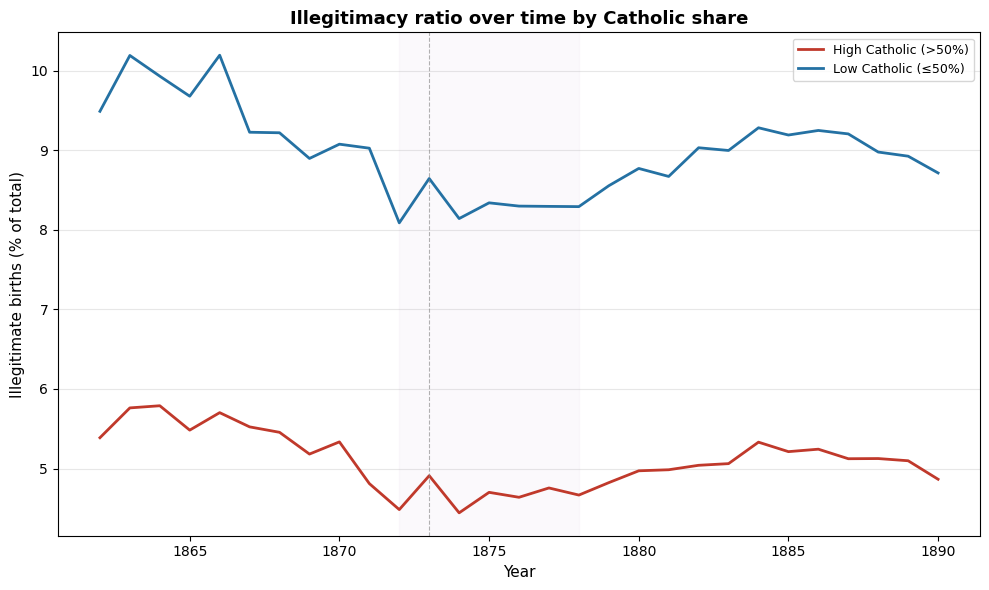

In [5]:
ill = illegitimacy_analysis(panel)
ill["fig"].savefig(OUTPUTS / "fig10_illegitimacy.png", dpi=300, bbox_inches="tight")
plt.show()

# %% Cell 23: Infant mortality channel

INFANT MORTALITY CHANNEL (1875+ only due to data break)

DiD: Infant Mortality Rate ~ CathShare × (Year>=1880)
  β = -0.0234 (SE = 0.0177, p = 0.186)
  N = 6169
  Interpretation: relative change in rollback vs enforcement period

By sub-region (rollback vs enforcement):
  Polish provinces (24 counties): β = -0.2756 (SE = 0.1127, p = 0.015)
  German Catholic provinces (68 counties): β = 0.1923 (SE = 0.0360, p = 0.000)
  Protestant provinces (300 counties): β = -0.0717 (SE = 0.0332, p = 0.031)


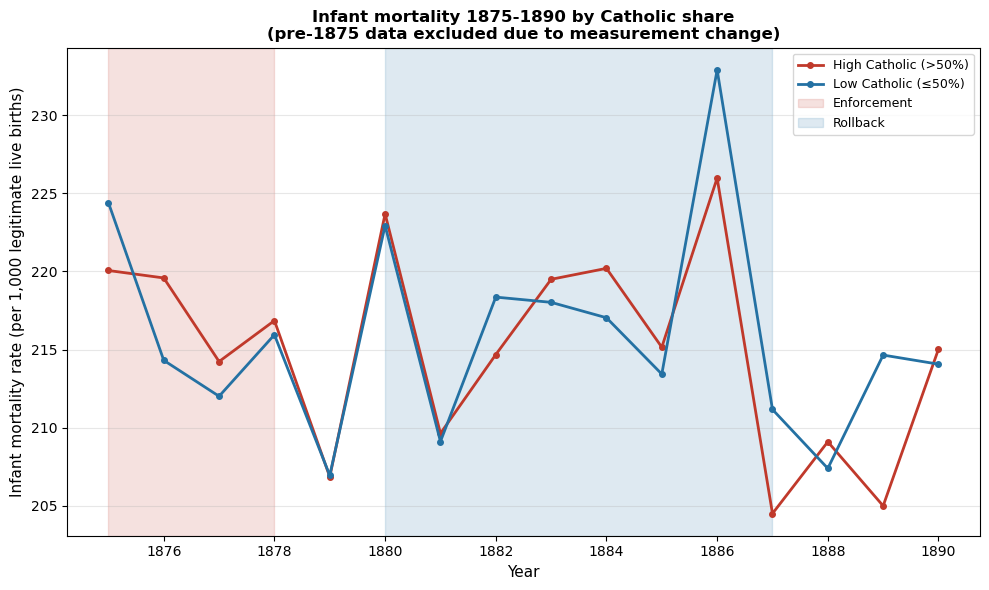

In [7]:
imr = infant_mortality_analysis(panel)
imr["fig"].savefig(OUTPUTS / "fig11_infant_mortality.png", dpi=300, bbox_inches="tight")
plt.show()

# %% Cell 24: Franco-Prussian War

FRANCO-PRUSSIAN WAR (1870-1871) ANALYSIS

Mean year-on-year change in CBR by Catholic share group:
  1870: Low=+0.45, High=+0.94, Diff=+0.50
  1871: Low=-4.08, High=-5.19, Diff=-1.11
  1872: Low=+5.01, High=+5.56, Diff=+0.56
  1873: Low=-0.10, High=-0.22, Diff=-0.11

DiD around war shock (1868-1874, war years = 1871-1872):
  Catholic share × War: β = -0.0077 (SE = 0.0051, p = 0.132)
  → Catholic counties' births fell by -0.008 more per 1,000 per pp Catholic during war


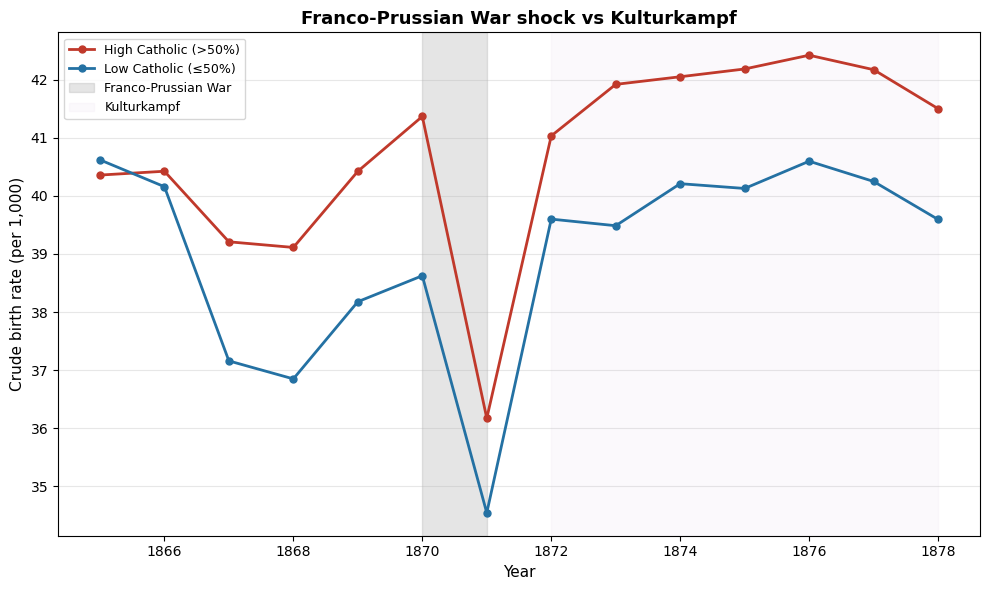

In [8]:
war = franco_prussian_war_analysis(panel)
war["fig"].savefig(OUTPUTS / "fig12_war_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

# %% Cell 25: Robustness — exclude war years

In [ ]:
war_rob = robustness_exclude_war(
    panel,
    outcome="cbr",
    war_years=(1870, 1871, 1872),
    ref_year=1869,
    savepath=str(OUTPUTS / "fig13_war_excluded_event_study.png"),
)
plt.show()

ImportError: cannot import name 'robustness_exclude_war' from 'src.advanced' (c:\Users\Anton\Demography\exam_project2\src\advanced.py)